In [2]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

# import scienceplots
import src.utils.setup_figures as figures



In [3]:
# style = ["dark_background"]
# plt.style.use(style)
figures.setup()
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

In [4]:
pre_data = pd.read_csv(r'Y:\DBM8\data\random_dot_motion\rt_test\26_1\DBM8_trial.csv', index_col=0)
unilateral_data = pd.read_csv(r'Y:\DBM8\data\random_dot_motion\rt_test\26_2\DBM8_trial.csv', index_col=0)
post_data = pd.read_csv(r'Y:\DBM8\data\random_dot_motion\rt_test\26_3\DBM8_trial.csv', index_col=0)

In [5]:
pre_data

,idx_valid,idx_correction,is_correction_trial,signed_coherence,target,choice,response_time,is_valid,outcome,trial_reward,...,reinforcement_duration,delay_duration,intertrial_duration,fixation_onset,stimulus_onset,response_onset,reinforcement_onset,delay_onset,intertrial_onset,stimulus_seed
idx_attempt,,,,,,,,,,,,,,,,,,,,,
1,1,0,False,100,1,1.0,2.066901,1,1.0,2.0,...,0,0.0,0.5,0:00:01.679944,0:00:02.265830,0:00:04.633735,0:00:04.683816,0:00:04.768502,0:00:04.825724,743908
2,2,0,False,100,1,1.0,0.549489,1,1.0,1.5,...,0,0.0,0.5,0:00:12.451944,0:00:13.060644,0:00:13.910503,0:00:13.961049,0:00:14.165364,0:00:14.207492,908548
3,3,0,False,-100,-1,-1.0,3.474233,1,1.0,1.5,...,0,0.0,0.5,0:00:15.359963,0:00:15.916905,0:00:19.691501,0:00:19.730036,0:00:19.904146,0:00:19.948121,233862
4,4,0,False,-100,-1,-1.0,1.923811,1,1.0,1.5,...,0,0.0,0.5,0:00:20.965986,0:00:21.639361,0:00:23.863496,0:00:23.905422,0:00:24.041048,0:00:24.084091,365019
5,5,0,False,-100,-1,-1.0,1.051142,1,1.0,1.5,...,0,0.0,0.5,0:00:25.401234,0:00:25.979644,0:00:27.332481,0:00:27.371340,0:00:27.529030,0:00:27.565791,255412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,178,0,False,-18,-1,-1.0,11.579017,1,1.0,1.5,...,0,0.0,0.5,0:39:00.199187,0:39:00.922680,0:39:12.803082,0:39:12.848036,0:39:13.004907,0:39:13.049390,84514
183,179,0,False,18,1,-1.0,15.451254,1,0.0,NaN,...,0,8.0,0.5,0:39:14.056514,0:39:14.690311,0:39:30.441911,0:39:30.484471,0:39:30.528928,0:39:38.547990,943820
184,180,0,False,100,1,1.0,34.718419,1,1.0,1.5,...,0,0.0,0.5,0:39:39.079651,0:39:39.668218,0:40:14.688138,0:40:14.727942,0:40:14.885502,0:40:14.921715,623911


In [6]:
# Find unique values in the column outcome
unique = pre_data['outcome'].unique()

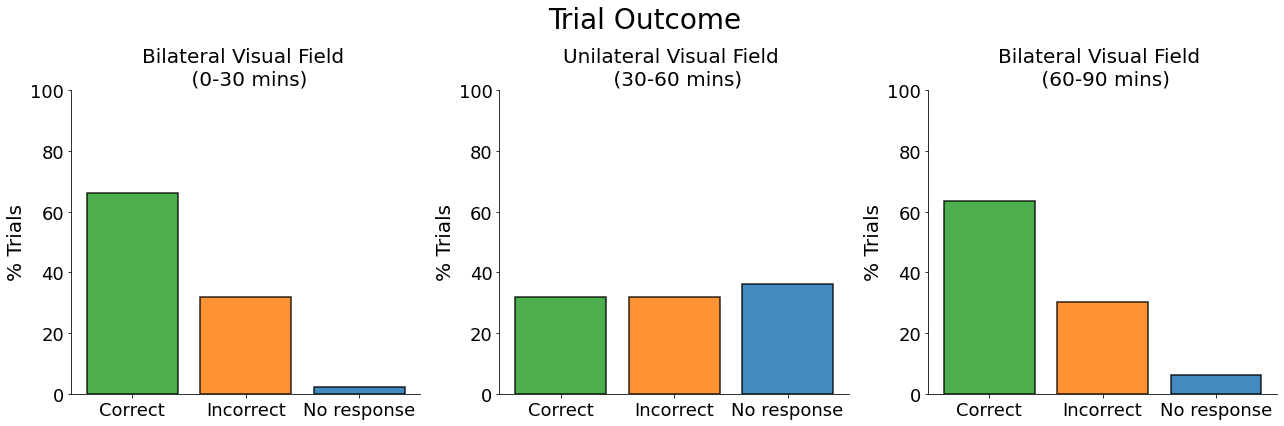

In [12]:
# Total attempts [correct, incorrect, no response]

# Create a bar plot of [total outcome=1, outcome=0, is_valid !=0] from all three sessions

titles = ["Bilateral Visual Field \n (0-30 mins)", "Unilateral Visual Field \n (30-60 mins)", "Bilateral Visual Field \n (60-90 mins)"]
color = ["#2ca02c", "#ff7f0e", "#1f77b4"]
# color = ['gray', '#f17105', '#e6c229']
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Trial Outcome", fontsize=28)

for i, data in enumerate([pre_data, unilateral_data, post_data]):
    x = (0,1,2)
    outcome = np.array([sum(data['outcome'] == 1)/data.shape[0], sum(data['outcome'] == 0)/data.shape[0], sum(data['is_valid'] == 0)/data.shape[0]])
    ax[i].bar(x, 100*outcome, color=color, alpha=0.85, edgecolor='black', linewidth=1.5)
    ax[i].set_title(titles[i], fontsize=20)
    ax[i].set_xticks([0, 1, 2], ["Correct", "Incorrect", "No response"], fontsize=18)
    ax[i].tick_params(axis='y', labelsize=18)
    ax[i].set_ylabel("% Trials", fontsize=20)
    ax[i].set_ylim(0, 100)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    
fig.tight_layout()
fig.show()


fig.savefig("../dissemination/figures/trial_outcome.png", dpi=400)
fig.savefig("../dissemination/figures/trial_outcome.svg", dpi=400)




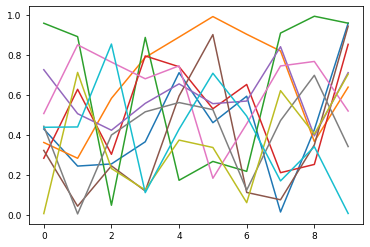

In [69]:
# see all the colors in color cycle
plt.figure()
for i in range(10):
    plt.plot(np.random.rand(10), color=colors[i])
plt.show()
